# Combined: FC inter-vs-intra + dataset-size composite (ts_young)

Side-by-side panel:

- **Left:** FC correlation on `test_inter` vs `test_intra` for Hopf, Neural SDE, Hybrid Hopf. Reads `results/ts_young_{model}.json` (the precomputed metrics used by `intra_vs_inter_barplots.ipynb`).
- **Right:** Composite FC-modeling score (mean of `fc_correlation`, `phase_fc_correlation`, `fcd_ks`, `phfcd_ks`, with ↑-better metrics flipped to `1 - v`) at N=10 vs N=94 on `test_intra`. Reads `results/runs/ts_young_{model}_n{N}_seed{S}.json` (same source as `dataset_size_sweep.ipynb`).

Both panels share the same three models and the same dataset; no merging of underlying data is required.

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)
project_root = Path.cwd()

plt.rcParams['figure.dpi'] = 140
%matplotlib inline

In [2]:
DATASET = 'ts_young'

# Shared model ordering across both panels.
MODELS = {
    'hopf':        'Hopf',
    'hybrid_hopf': 'Hybrid Hopf',
    'nsde':        'Neural SDE',
}
MODEL_KEYS = list(MODELS.keys())
MODEL_LABELS = [MODELS[m] for m in MODEL_KEYS]

# Left panel: inter vs intra full-data results (precomputed in results/).
FC_MODEL_COLORS = {
    'Hopf':        '#DD8452',  # salmon
    'Neural SDE':  '#4C72B0',  # blue
    'Hybrid Hopf': '#55A868',  # green
}
INTRA_INTER_RESULT = {
    'hopf':        Path('results') / f'{DATASET}_hopf.json',
    'nsde':        Path('results') / f'{DATASET}_nsde.json',
    'hybrid_hopf': Path('results') / f'{DATASET}_hybrid_hopf.json',
}

# Right panel: per-(size, seed) JSONs from results/runs/.
SIZES = [10, 25, 50, 94]
# All models have seeds 42-51 at N=10 and N=94 (hopf is missing seed 45 at n=94).
# Wilcoxon handles NaN gaps. Intermediate sizes (25, 50) only exist for 42-44 but
# are not plotted here (SHOW_SIZES only uses 10 and 94).
SEEDS = list(range(42, 52))
SHOW_SIZES = [10, 94]
SPLIT = 'test_intra'
COMPOSITE_INCLUDE = ['fc_correlation', 'phase_fc_correlation', 'fcd_ks', 'phfcd_ks']
HIGHER_IS_BETTER = {'fc_correlation', 'phase_fc_correlation'}
OLD_COLOR = '#C0C0C0'  # N=10
NEW_COLOR = '#104870'  # N=94

RUNS_DIR = project_root / 'results' / 'runs'

In [3]:
def load_fc_intra_inter(model_key):
    """Return (inter_mean, inter_std, intra_mean, intra_std) for fc_correlation."""
    path = INTRA_INTER_RESULT[model_key]
    payload = json.loads(path.read_text())
    inter = payload['metrics']['test_inter']
    intra = payload['metrics']['test_intra']
    return (
        float(inter['fc_correlation']),
        float(inter.get('fc_correlation_std', 0.0)),
        float(intra['fc_correlation']),
        float(intra.get('fc_correlation_std', 0.0)),
    )


def load_metric_grid(model_key, metric_key, split='test_intra'):
    """Return ndarray (n_sizes, n_seeds), NaN for missing files."""
    out = np.full((len(SIZES), len(SEEDS)), np.nan)
    for ni, n in enumerate(SIZES):
        for si, s in enumerate(SEEDS):
            path = RUNS_DIR / f'{DATASET}_{model_key}_n{n}_seed{s}.json'
            if not path.exists():
                continue
            payload = json.loads(path.read_text())
            v = payload['metrics'][split].get(metric_key)
            if v is not None:
                out[ni, si] = float(v)
    return out


def composite_score_grid(model_key, split):
    """Per-seed mean across COMPOSITE_INCLUDE, with ↑-better metrics flipped to (1 - v).
    Returns ndarray (n_sizes, n_seeds), lower = better."""
    stack = []
    for k in COMPOSITE_INCLUDE:
        g = load_metric_grid(model_key, k, split=split)
        stack.append(1.0 - g if k in HIGHER_IS_BETTER else g)
    return np.nanmean(np.stack(stack, axis=0), axis=0)

/tmp/claude-213898/ipykernel_3979210/2335084015.py:37: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(stack, axis=0), axis=0)


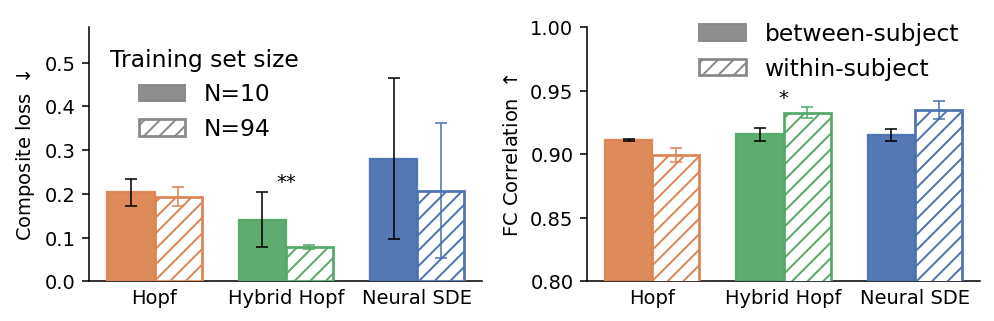

Saved combined figure to paper/images*/comparison/ts_young_fc_intra_vs_inter_AND_size_sweep_composite.{pdf,png,svg}


In [4]:
from scipy.stats import wilcoxon


def _sig_marker(p):
    if p is None or np.isnan(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def paired_wilcoxon(a, b):
    """Two-sided paired Wilcoxon p-value. Returns NaN when undefined."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    a, b = a[mask], b[mask]
    if a.size < 2 or np.allclose(a, b):
        return float('nan')
    try:
        _, p = wilcoxon(a, b, zero_method='wilcox', alternative='two-sided')
    except ValueError:
        return float('nan')
    return float(p)


def load_seed_inter_intra(model_key, metric_key='fc_correlation', n=94, seeds=SEEDS):
    """Per-seed (inter, intra) arrays from results/runs/{ds}_{model}_n{n}_seed{s}.json."""
    inter = np.full(len(seeds), np.nan)
    intra = np.full(len(seeds), np.nan)
    for si, s in enumerate(seeds):
        path = RUNS_DIR / f'{DATASET}_{model_key}_n{n}_seed{s}.json'
        if not path.exists():
            continue
        payload = json.loads(path.read_text())
        v_inter = payload['metrics']['test_inter'].get(metric_key)
        v_intra = payload['metrics']['test_intra'].get(metric_key)
        if v_inter is not None:
            inter[si] = float(v_inter)
        if v_intra is not None:
            intra[si] = float(v_intra)
    return inter, intra


fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(7.2, 2.4))
fig.patch.set_alpha(0.0)

x = np.arange(len(MODEL_LABELS))
bar_width = 0.36

# ---- Left panel: composite score, N=10 vs N=94 ---------------------------
# Same encoding as the right panel: per-model colour, solid for the first
# condition (N=10) and white-with-hatch for the second (N=94).
size_idx = [SIZES.index(n) for n in SHOW_SIZES]
low_mean, low_std, high_mean, high_std = [], [], [], []
left_pvals = {}  # model_key -> p
for m in MODEL_KEYS:
    grid = composite_score_grid(m, SPLIT)[size_idx]  # (2, S)
    means = np.nanmean(grid, axis=1)
    stds = np.nanstd(grid, axis=1, ddof=1) if grid.shape[1] > 1 else np.zeros_like(means)
    low_mean.append(means[0]);  low_std.append(stds[0])
    high_mean.append(means[1]); high_std.append(stds[1])
    left_pvals[m] = paired_wilcoxon(grid[0], grid[1])

for i, mkey in enumerate(MODEL_KEYS):
    color = FC_MODEL_COLORS[MODELS[mkey]]
    ax_left.bar(
        x[i] - bar_width / 2, low_mean[i], bar_width,
        yerr=low_std[i],
        facecolor=color, edgecolor=color, linewidth=1.2,
        capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
        zorder=3, alpha=0.95,
    )
    ax_left.bar(
        x[i] + bar_width / 2, high_mean[i], bar_width,
        yerr=high_std[i],
        facecolor='white', edgecolor=color, linewidth=1.4,
        hatch='///',
        capsize=3, error_kw=dict(lw=0.8, capthick=0.8, ecolor=color),
        zorder=3,
    )

ax_left.set_xticks(x)
ax_left.set_xticklabels(MODEL_LABELS, fontsize=10)
ax_left.set_ylabel('Composite loss $\\downarrow$', fontsize=10)
y_top = max(
    max(lm + ls for lm, ls in zip(low_mean, low_std)),
    max(hm + hs for hm, hs in zip(high_mean, high_std)),
)
ax_left.set_ylim(0, y_top * 1.25)
ax_left.set_axisbelow(True)
ax_left.tick_params(axis='x', length=0)
for spine in ('top', 'right'):
    ax_left.spines[spine].set_visible(False)

# Significance markers above each pair of bars.
for i, mkey in enumerate(MODEL_KEYS):
    marker = _sig_marker(left_pvals[mkey])
    if not marker:
        continue
    top = max(low_mean[i] + low_std[i], high_mean[i] + high_std[i])
    ax_left.text(x[i], top, marker,
                 ha='center', va='bottom', fontsize=10)

size_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#888888', edgecolor='#888888', alpha=0.95),
    plt.Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='#888888', hatch='///', linewidth=1.4),
]
ax_left.legend(
    size_handles, [f'N={SHOW_SIZES[0]}', f'N={SHOW_SIZES[-1]}'],
    loc='upper left', frameon=False, fontsize=12, ncols=1,
    title='Training set size', title_fontsize=12,
    bbox_to_anchor=(0.0, 1.0)
)

# ---- Right panel: FC correlation, Inter vs Intra --------------------------
# Significance is computed across seeds from results/runs/{ds}_{model}_n94_seed*.
right_pvals = {}
for i, mkey in enumerate(MODEL_KEYS):
    label = MODELS[mkey]
    inter_mean, inter_std, intra_mean, intra_std = load_fc_intra_inter(mkey)
    color = FC_MODEL_COLORS[label]
    ax_right.bar(
        x[i] - bar_width / 2, inter_mean, bar_width,
        yerr=inter_std,
        facecolor=color, edgecolor=color, linewidth=1.2,
        capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
        zorder=3, alpha=0.95,
    )
    ax_right.bar(
        x[i] + bar_width / 2, intra_mean, bar_width,
        yerr=intra_std,
        facecolor='white', edgecolor=color, linewidth=1.4,
        hatch='///',
        capsize=3, error_kw=dict(lw=0.8, capthick=0.8, ecolor=color),
        zorder=3,
    )
    # Paired Wilcoxon across seeds at n=94 (fc_correlation).
    inter_seeds, intra_seeds = load_seed_inter_intra(mkey, 'fc_correlation', n=94)
    right_pvals[mkey] = paired_wilcoxon(inter_seeds, intra_seeds)
    marker = _sig_marker(right_pvals[mkey])
    if marker:
        top = max(inter_mean + inter_std, intra_mean + intra_std)
        ax_right.text(x[i], top, marker,
                      ha='center', va='bottom', fontsize=10)

ax_right.set_xticks(x)
ax_right.set_xticklabels(MODEL_LABELS, fontsize=10)
ax_right.set_ylim(0.8, 1.0)
ax_right.set_ylabel('FC Correlation $\\uparrow$', fontsize=10)
ax_right.set_axisbelow(True)
ax_right.xaxis.grid(False)
ax_right.tick_params(axis='x', length=0)
for spine in ('top', 'right'):
    ax_right.spines[spine].set_visible(False)

split_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#888888', edgecolor='#888888', alpha=0.95),
    plt.Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='#888888', hatch='///', linewidth=1.4),
]
ax_right.legend(
    split_handles, ['between-subject', 'within-subject'],
    loc='upper right', fontsize=12, frameon=False, ncols=1, bbox_to_anchor=(1.0, 1.1)  # position
)


plt.tight_layout()

out_dir_pdf = Path('paper_new/images/comparison')
out_dir_png = Path('paper_new/images_png/comparison')
out_dir_svg = Path('paper_new/images_svg/comparison')
for d in (out_dir_pdf, out_dir_png, out_dir_svg):
    d.mkdir(parents=True, exist_ok=True)
base = f'{DATASET}_fc_intra_vs_inter_AND_size_sweep_composite'
plt.savefig(out_dir_pdf / f'{base}.pdf', bbox_inches='tight', dpi=200)
plt.savefig(out_dir_png / f'{base}.png', bbox_inches='tight', dpi=200)
plt.savefig(out_dir_svg / f'{base}.svg', bbox_inches='tight')
plt.show()
print(f'Saved combined figure to paper/images*/comparison/{base}.{{pdf,png,svg}}')

In [5]:
# Paired Wilcoxon tables: per model, across seeds.
#   Left panel  → composite loss at N=10 vs N=94 (test_intra).
#   Right panel → FC corr at n=94, test_inter vs test_intra.
print(f'Paired Wilcoxon signed-rank test (per model, across {len(SEEDS)} seeds).')
print(f'Seeds: {SEEDS}')

print('\n== Left panel: composite loss, N=10 vs N=94 (test_intra) ==')
size_idx = [SIZES.index(n) for n in SHOW_SIZES]
header = f'{"model":<14} {"N=10 mean":>10} {"N=94 mean":>10} {"N94-N10":>10} {"p":>8} {"sig":>5}'
print(header)
print('-' * len(header))
for mkey in MODEL_KEYS:
    grid = composite_score_grid(mkey, SPLIT)[size_idx]  # (2, S)
    low_v, high_v = grid[0], grid[1]
    p = paired_wilcoxon(low_v, high_v)
    print(
        f'{MODELS[mkey]:<14} {np.nanmean(low_v):>10.4f} {np.nanmean(high_v):>10.4f} '
        f'{np.nanmean(high_v) - np.nanmean(low_v):>+10.4f} {p:>8.3f} {_sig_marker(p):>5}'
    )

print('\n== Right panel: FC correlation, between-subject vs within-subject (n=94) ==')
header = f'{"model":<14} {"inter mean":>11} {"intra mean":>11} {"intra-inter":>12} {"p":>8} {"sig":>5}'
print(header)
print('-' * len(header))
for mkey in MODEL_KEYS:
    inter_v, intra_v = load_seed_inter_intra(mkey, 'fc_correlation', n=94)
    p = paired_wilcoxon(inter_v, intra_v)
    print(
        f'{MODELS[mkey]:<14} {np.nanmean(inter_v):>11.4f} {np.nanmean(intra_v):>11.4f} '
        f'{np.nanmean(intra_v) - np.nanmean(inter_v):>+12.4f} {p:>8.3f} {_sig_marker(p):>5}'
    )
print('\nSignificance: * p<0.05, ** p<0.01, *** p<0.001')

Paired Wilcoxon signed-rank test (per model, across 10 seeds).
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

== Left panel: composite loss, N=10 vs N=94 (test_intra) ==
model           N=10 mean  N=94 mean    N94-N10        p   sig
--------------------------------------------------------------


/tmp/claude-213898/ipykernel_3979210/2335084015.py:37: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(stack, axis=0), axis=0)


Hopf               0.2035     0.1936    -0.0098    0.359      


Hybrid Hopf        0.1409     0.0775    -0.0634    0.004    **


Neural SDE         0.2808     0.2071    -0.0737    0.064      

== Right panel: FC correlation, between-subject vs within-subject (n=94) ==
model           inter mean  intra mean  intra-inter        p   sig
------------------------------------------------------------------
Hopf                0.9128      0.9066      -0.0061    0.359      
Hybrid Hopf         0.9258      0.9366      +0.0108    0.014     *
Neural SDE          0.8018      0.8026      +0.0008    0.695      

Significance: * p<0.05, ** p<0.01, *** p<0.001
